# Evaluación grupal: respuestas a las 10 preguntas

**Proyecto:** Sistema de recomendación de películas con MovieLens
**Fecha:** Septiembre 2026

Cada pregunta tiene su **respuesta** y, debajo, las celdas de **código que la demuestran**. Todos los números de las respuestas salen de esas celdas.

Se trabaja con dos versiones del dataset MovieLens:

- **MovieLens 1M** (1.000.209 calificaciones): el sistema de recomendación. Preguntas 1, 2, 3, 7 y 9. El código viene de [`03a_baselines.py`](WRANGLER/04_modelado/scripts/03a_baselines.py), [`03b_mf_numpy.py`](WRANGLER/04_modelado/scripts/03b_mf_numpy.py) y [`03c_antes_despues.py`](WRANGLER/04_modelado/scripts/03c_antes_despues.py).
- **ml-latest-small** (100.836 calificaciones): el árbol de decisión. Preguntas 3 a 10. El código viene de [`arbol_decision_movielens.ipynb`](arbol_decision_movielens.ipynb) y [`script.py`](script.py).

**Para ejecutarlo:** elegir el kernel `.venv` (creado con [`requirements.txt`](requirements.txt)) y usar *Ejecutar todo*. Tarda unos 15 segundos.

<a id="pregunta-0"></a>

## 0. Carga de datos

Se importan las librerías y se cargan los dos datasets. Si falta algún archivo, la celda indica cuál.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)
SEED = 42

In [2]:
ML1M = Path("WRANGLER/03_preparacion_datos/datos/datos_limpios.parquet")
SMALL = Path("ml-latest-small")
for ruta in (ML1M, SMALL / "ratings.csv", SMALL / "movies.csv", SMALL / "tags.csv", SMALL / "links.csv"):
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró {ruta}. Abre el cuaderno desde la raíz del repositorio.")

ml1m = pd.read_parquet(ML1M)
ratings = pd.read_csv(SMALL / "ratings.csv", encoding="utf-8")
movies = pd.read_csv(SMALL / "movies.csv", encoding="utf-8")
tags = pd.read_csv(SMALL / "tags.csv", encoding="utf-8")
links = pd.read_csv(SMALL / "links.csv", encoding="utf-8")
print(f"MovieLens 1M:    {len(ml1m):,} calificaciones")
print(f"ml-latest-small: {len(ratings):,} calificaciones")

MovieLens 1M:    1,000,209 calificaciones
ml-latest-small: 100,836 calificaciones


---
<a id="pregunta-1"></a>

## 1. ¿Qué problema concreto aborda su proyecto?

**Respuesta:** Los usuarios conocen una parte mínima del catálogo y la actividad se concentra en pocas películas (MovieLens 1M):

- El usuario mediano solo vio 96 de 3.706 películas (2,6%). El 97,4% del catálogo le es desconocido.
- El 80% de las calificaciones cae sobre 1.182 películas (31,9% del catálogo). El 68,1% restante se reparte solo el 20% de la actividad (cola larga).

**Decisión a apoyar:** implementar un sistema de recomendación por filtrado colaborativo que personalice las sugerencias, en lugar de mostrar siempre las mismas películas populares.

**Criterios de éxito de negocio:**

- **CN-1:** que la predicción se desvíe menos de 0,70 estrellas de la nota real (MAE < 0,70).
- **CN-2:** mejorar en al menos un 10% el error del ranking por popularidad (RMSE 0,977).
- **CN-3:** que el Top-10 recomendado cubra más del 31,9% del catálogo.
- **CN-4:** dar recomendaciones a los 6.040 usuarios, incluidos los 1.743 (28,9%) que vieron menos de 50 películas.

El cumplimiento de cada criterio se mide en la [sección 9.3](#seccion-9-3).

<a id="seccion-1-1"></a>

### 1.1 El problema en números

Se calcula, a partir de [`datos_limpios.parquet`](WRANGLER/03_preparacion_datos/datos/datos_limpios.parquet), cuántas películas ve cada usuario y cuántas películas concentran el 80% de las calificaciones. Son las mismas cifras de [`3_1_objetivo_del_negocio.txt`](WRANGLER/01_comprension_negocio/3_1_objetivo_del_negocio.txt).

In [3]:
vistas_por_usuario = ml1m.groupby("userId").size()
votos_por_pelicula = ml1m.groupby("movieId").size().sort_values(ascending=False)
n_usuarios = ml1m["userId"].nunique()
n_peliculas = ml1m["movieId"].nunique()

acumulado = votos_por_pelicula.cumsum() / votos_por_pelicula.sum()
peliculas_80 = int((acumulado < 0.80).sum()) + 1
mediana_vistas = vistas_por_usuario.median()
usuarios_menos_50 = int((vistas_por_usuario < 50).sum())

problema = pd.DataFrame([
    ("Usuarios", f"{n_usuarios:,}"),
    ("Películas calificadas", f"{n_peliculas:,}"),
    ("Mediana de películas vistas por usuario", f"{mediana_vistas:.0f}"),
    ("Catálogo que conoce el usuario mediano", f"{mediana_vistas / n_peliculas:.1%}"),
    ("Catálogo desconocido para el usuario mediano", f"{1 - mediana_vistas / n_peliculas:.1%}"),
    ("Películas que concentran el 80% de la actividad", f"{peliculas_80:,} ({peliculas_80 / n_peliculas:.1%})"),
    ("Catálogo en la cola larga", f"{1 - peliculas_80 / n_peliculas:.1%}"),
    ("Usuarios con menos de 50 películas vistas", f"{usuarios_menos_50:,} ({usuarios_menos_50 / n_usuarios:.1%})"),
], columns=["indicador", "valor"])
display(problema)

,indicador,valor
0,Usuarios,"6,040"
1,Películas calificadas,"3,706"
2,Mediana de películas vistas por usuario,96
3,Catálogo que conoce el usuario mediano,2.6%
4,Catálogo desconocido para el usuario mediano,97.4%
5,Películas que concentran el 80% de la actividad,"1,182 (31.9%)"
6,Catálogo en la cola larga,68.1%
7,Usuarios con menos de 50 películas vistas,"1,743 (28.9%)"


---
<a id="pregunta-2"></a>

## 2. ¿Cuál es la métrica principal y cómo se calcula?

**Respuesta:** RMSE (raíz del error cuadrático medio), en estrellas.

**Fórmula:** RMSE = √( (1/|T|) × Σ (r(u,i) − r_pred(u,i))² )

- **T:** conjunto de prueba (200.042 calificaciones, el 20%).
- **r(u,i):** calificación real (de 1 a 5). **r_pred(u,i):** calificación que predice el modelo, recortada a [1, 5].
- **Unidad:** estrellas. Un RMSE de 0,85 significa que el modelo se equivoca en unas 0,85 estrellas.
- **Valor obtenido:** 0,851 con el modelo de factorización matricial, frente a 0,977 del ranking por popularidad (práctica actual). Es un 12,9% mejor.
- **Meta:** RMSE ≤ 0,90 → **se cumple**.
- **Tipo:** métrica de rendimiento del modelo. Se conecta con el negocio a través de CN-2.
- **Cómo mejorarla:** probar otros hiperparámetros (k, reg, lr) y validar con validación cruzada de 5 particiones.

<a id="seccion-2-1"></a>

### 2.1 Modelos de referencia (baselines)

Antes de entrenar el modelo se miden cuatro predictores simples, con la misma división 80/20. Sirven para saber si el modelo aporta algo. Código de [`03a_baselines.py`](WRANGLER/04_modelado/scripts/03a_baselines.py).

In [4]:
datos = ml1m[["userId", "movieId", "rating"]]
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(datos))
corte = int(len(datos) * 0.8)
train = datos.iloc[idx[:corte]].reset_index(drop=True)
test = datos.iloc[idx[corte:]].reset_index(drop=True)
real = test["rating"].to_numpy(float)
print(f"Entrenamiento: {len(train):,} | Prueba: {len(test):,}")


def rmse_mae(pred, real):
    error = real - np.clip(pred, 1.0, 5.0)
    return float(np.sqrt((error ** 2).mean())), float(np.abs(error).mean())

Entrenamiento: 800,167 | Prueba: 200,042


In [5]:
LAMBDA = 2.0
mu = train["rating"].mean()
media_usuario = train.groupby("userId")["rating"].mean()
media_pelicula = train.groupby("movieId")["rating"].mean()

desvio = train["rating"] - mu
g = desvio.groupby(train["movieId"])
b_i = g.sum() / (LAMBDA + g.size())
desvio2 = desvio - train["movieId"].map(b_i)
g = desvio2.groupby(train["userId"])
b_u = g.sum() / (LAMBDA + g.size())

predicciones = {
    "Media global": np.full(len(test), mu),
    "Media por usuario": test["userId"].map(media_usuario).fillna(mu).to_numpy(float),
    "Media por película (popularidad)": test["movieId"].map(media_pelicula).fillna(mu).to_numpy(float),
    "Media + sesgos (mu + b_u + b_i)": (mu + test["userId"].map(b_u).fillna(0)
                                         + test["movieId"].map(b_i).fillna(0)).to_numpy(float),
}
escalera = pd.DataFrame([(nombre, *rmse_mae(p, real)) for nombre, p in predicciones.items()],
                        columns=["modelo", "RMSE", "MAE"])
display(escalera)

,modelo,RMSE,MAE
0,Media global,1.1167,0.9328
1,Media por usuario,1.0344,0.8273
2,Media por película (popularidad),0.9765,0.7800
3,Media + sesgos (mu + b_u + b_i),0.9051,0.7150


<a id="seccion-2-2"></a>

### 2.2 Entrenamiento del modelo (factorización matricial)

El modelo predice r(u,i) = μ + b_u + b_i + p_u · q_i y se entrena solo con el 80% de entrenamiento. Se detiene cuando el error deja de bajar durante 6 épocas (parada temprana). Código de [`03b_mf_numpy.py`](WRANGLER/04_modelado/scripts/03b_mf_numpy.py), con los hiperparámetros de [`mf_numpy.json`](WRANGLER/04_modelado/resultados/mf_numpy.json).

In [6]:
K, LR, REG, EPOCAS, LOTE, PACIENCIA = 32, 0.02, 0.045, 45, 4096, 6

cod_u = datos["userId"].astype("category")
cod_i = datos["movieId"].astype("category")
U = cod_u.cat.codes.to_numpy(np.int32)
I = cod_i.cat.codes.to_numpy(np.int32)
R = datos["rating"].to_numpy(np.float32)
n_u, n_i = len(cod_u.cat.categories), len(cod_i.cat.categories)

tr_idx, te_idx = idx[:corte], idx[corte:]
U_tr, I_tr, R_tr = U[tr_idx], I[tr_idx], R[tr_idx]
U_te, I_te, R_te = U[te_idx], I[te_idx], R[te_idx]
mu_mf = R_tr.mean()

gen = np.random.default_rng(7)
P = gen.normal(0, 0.05, (n_u, K)).astype(np.float32)
Q = gen.normal(0, 0.05, (n_i, K)).astype(np.float32)
bu = np.zeros(n_u, np.float32)
bi = np.zeros(n_i, np.float32)
print(f"{n_u:,} usuarios x {n_i:,} películas, {K} factores latentes")

6,040 usuarios x 3,706 películas, 32 factores latentes


In [7]:
historial, mejor, sin_mejora = [], None, 0
orden = np.arange(len(tr_idx))
for epoca in range(1, EPOCAS + 1):
    gen.shuffle(orden)
    for s in range(0, len(orden), LOTE):
        b = orden[s:s + LOTE]
        u, i, r = U_tr[b], I_tr[b], R_tr[b]
        pu, qi = P[u], Q[i]
        err = r - (mu_mf + bu[u] + bi[i] + np.einsum("ij,ij->i", pu, qi))
        e = err[:, None]
        np.add.at(bu, u, LR * (err - REG * bu[u]))
        np.add.at(bi, i, LR * (err - REG * bi[i]))
        np.add.at(P, u, LR * (e * qi - REG * pu))
        np.add.at(Q, i, LR * (e * pu - REG * qi))
    pred_te = mu_mf + bu[U_te] + bi[I_te] + np.einsum("ij,ij->i", P[U_te], Q[I_te])
    rmse_ep, mae_ep = rmse_mae(pred_te, R_te)
    historial.append((epoca, rmse_ep, mae_ep))
    if mejor is None or rmse_ep < mejor[1]:
        mejor = (epoca, rmse_ep, mae_ep, P.copy(), Q.copy(), bu.copy(), bi.copy())
        sin_mejora = 0
    else:
        sin_mejora += 1
        if sin_mejora >= PACIENCIA:
            break

mejor_epoca, rmse_mf, mae_mf, P, Q, bu, bi = mejor
print(f"Mejor época: {mejor_epoca} (se detuvo en la época {len(historial)})")
print(f"RMSE = {rmse_mf:.4f} | MAE = {mae_mf:.4f}")

Mejor época: 14 (se detuvo en la época 20)
RMSE = 0.8510 | MAE = 0.6686


<a id="seccion-2-3"></a>

### 2.3 Resultado: el modelo frente a los baselines

Se compara el RMSE del modelo con los cuatro baselines y se calcula cuánto mejora frente a la popularidad, que es la práctica actual.

In [8]:
rmse_pop = escalera.loc[2, "RMSE"]
resultado = pd.concat([escalera, pd.DataFrame([{"modelo": "Factorización matricial", "RMSE": rmse_mf, "MAE": mae_mf}])],
                      ignore_index=True)
resultado["mejora vs popularidad (%)"] = (rmse_pop - resultado["RMSE"]) / rmse_pop * 100
display(resultado)
print(f"Meta RMSE <= 0.90: {'CUMPLE' if rmse_mf <= 0.90 else 'NO CUMPLE'} (RMSE = {rmse_mf:.4f})")

,modelo,RMSE,MAE,mejora vs popularidad (%)
0,Media global,1.1167,0.9328,-14.3583
1,Media por usuario,1.0344,0.8273,-5.9283
2,Media por película (popularidad),0.9765,0.7800,0.0000
3,Media + sesgos (mu + b_u + b_i),0.9051,0.7150,7.3088
4,Factorización matricial,0.8510,0.6686,12.8559


Meta RMSE <= 0.90: CUMPLE (RMSE = 0.8510)


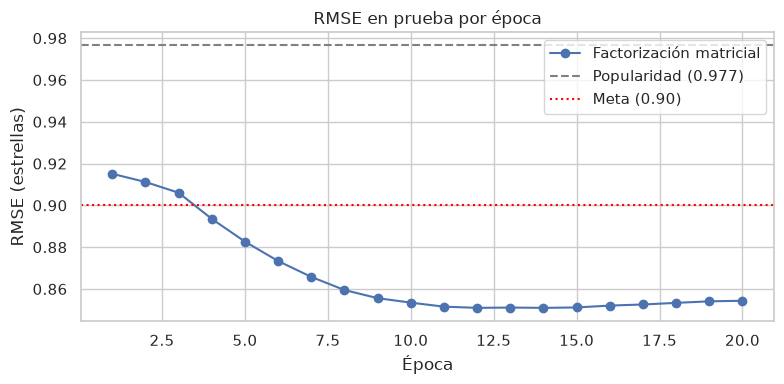

In [9]:
curva = pd.DataFrame(historial, columns=["época", "RMSE", "MAE"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curva["época"], curva["RMSE"], marker="o", label="Factorización matricial")
ax.axhline(rmse_pop, color="gray", linestyle="--", label=f"Popularidad ({rmse_pop:.3f})")
ax.axhline(0.90, color="red", linestyle=":", label="Meta (0.90)")
ax.set(title="RMSE en prueba por época", xlabel="Época", ylabel="RMSE (estrellas)")
ax.legend()
fig.tight_layout()
plt.show()

---
<a id="pregunta-3"></a>

## 3. ¿Cuál es la unidad de análisis y cuántos registros/variables tiene?

**Respuesta:** La unidad de análisis es el par **(usuario, película)**: cada fila es la calificación que un usuario dio a una película. Los datos vienen de MovieLens (GroupLens; Harper & Konstan, 2015).

| Dataset | Uso | Calificaciones | Usuarios | Películas | Variables |
|---|---|---:|---:|---:|---:|
| MovieLens 1M | Recomendador | 1.000.209 | 6.040 | 3.706 | 9 |
| ml-latest-small | Árbol de decisión | 100.836 | 610 | 9.724 calificadas de 9.742 | 4 |

- **Archivos de ml-latest-small:** ratings.csv (100.836 × 4), movies.csv (9.742 × 3), tags.csv (3.683 × 4) y links.csv (9.742 × 3).
- **MovieLens 1M después de la preparación:** matriz de 6.040 × 3.706 con el 4,47% de celdas con dato; 800.167 calificaciones para entrenar y 200.042 para probar.
- **ml-latest-small después de la preparación:** 100.836 observaciones con 4 variables; 80.668 para entrenar y 20.168 para probar.

<a id="seccion-3-1"></a>

### 3.1 Dimensiones de los datasets

Se muestran las filas y columnas de cada archivo y el tamaño de la matriz usuario × película.

In [10]:
dimensiones = pd.DataFrame([
    ("MovieLens 1M / datos_limpios.parquet", *ml1m.shape),
    ("ml-latest-small / ratings.csv", *ratings.shape),
    ("ml-latest-small / movies.csv", *movies.shape),
    ("ml-latest-small / tags.csv", *tags.shape),
    ("ml-latest-small / links.csv", *links.shape),
], columns=["archivo", "filas", "columnas"])
display(dimensiones)

celdas_matriz = n_usuarios * n_peliculas
print(f"MovieLens 1M: {n_usuarios:,} usuarios x {n_peliculas:,} películas = {celdas_matriz:,} celdas,"
      f" con dato {len(ml1m):,} ({len(ml1m) / celdas_matriz:.2%})")
print(f"ml-latest-small: {ratings['userId'].nunique():,} usuarios,"
      f" {ratings['movieId'].nunique():,} películas calificadas de {len(movies):,}")

,archivo,filas,columnas
0,MovieLens 1M / datos_limpios.parquet,1000209,9
1,ml-latest-small / ratings.csv,100836,4
2,ml-latest-small / movies.csv,9742,3
3,ml-latest-small / tags.csv,3683,4
4,ml-latest-small / links.csv,9742,3


MovieLens 1M: 6,040 usuarios x 3,706 películas = 22,384,240 celdas, con dato 1,000,209 (4.47%)
ml-latest-small: 610 usuarios, 9,724 películas calificadas de 9,742


---
<a id="pregunta-4"></a>

## 4. ¿Qué problemas de calidad encontraron y qué preparación aplicaron?

**Respuesta:**

**Problemas de calidad (ml-latest-small):**

- **Valores faltantes:** solo 8, en [`links.csv`](ml-latest-small/links.csv) (columna tmdbId, 0,08%).
- **Valores atípicos (método IQR):** 4.181 en el valor del rating, 70 en ratings por usuario, 1.179 en ratings por película y 225 en tags por película. No se eliminaron porque son valores válidos (ratings de 0,5 o 1, y usuarios o películas muy activos), no errores.
- **Sin duplicados ni valores fuera de rango.** MovieLens 1M tampoco tiene nulos, duplicados ni valores fuera de rango.

**Preparación aplicada para el árbol de decisión:**

1. Variable objetivo `rating_alto`: 1 si el rating es ≥ 4, y 0 si no.
2. Variables nuevas: genre_count, user_mean_rating, user_rating_count y year.
3. Filas con valores vacíos: no había ninguna, así que se conservan las 100.836.
4. División 80/20 estratificada ([sección 7.1](#seccion-7-1)).

**Limitación:** las estadísticas del usuario se calcularon antes de dividir los datos, lo que produce fuga de información. Su efecto se mide en la [sección 7.3](#seccion-7-3).

**Preparación del recomendador:** división 80/20 con semilla 42; medias, sesgos y factores calculados solo con los datos de entrenamiento.

<a id="seccion-4-1"></a>

### 4.1 Valores faltantes, duplicados y rango

Se cuentan los valores vacíos de cada columna, los pares (usuario, película) repetidos y los ratings fuera de la escala.

In [11]:
archivos = {"ratings.csv": ratings, "movies.csv": movies, "tags.csv": tags, "links.csv": links}
faltantes = pd.DataFrame([(nombre, col, int(tabla[col].isna().sum()), tabla[col].isna().mean() * 100)
                          for nombre, tabla in archivos.items() for col in tabla.columns],
                         columns=["archivo", "columna", "faltantes", "% faltante"])
display(faltantes[faltantes["faltantes"] > 0])

print(f"ml-latest-small -> duplicados: {ratings.duplicated(['userId', 'movieId']).sum()},"
      f" fuera de [0.5, 5]: {(~ratings['rating'].between(0.5, 5)).sum()}")
print(f"MovieLens 1M    -> nulos: {int(ml1m[['userId', 'movieId', 'rating']].isna().sum().sum())},"
      f" duplicados: {ml1m.duplicated(['userId', 'movieId']).sum()},"
      f" fuera de [1, 5]: {(~ml1m['rating'].between(1, 5)).sum()}")

,archivo,columna,faltantes,% faltante
13,links.csv,tmdbId,8,0.0821


ml-latest-small -> duplicados: 0, fuera de [0.5, 5]: 0


MovieLens 1M    -> nulos: 0, duplicados: 0, fuera de [1, 5]: 0


<a id="seccion-4-2"></a>

### 4.2 Valores atípicos (IQR)

Mismo criterio que [`script.py`](script.py): es atípico lo que queda fuera de Q1 − 1,5·IQR y Q3 + 1,5·IQR.

In [12]:
def atipicos_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum())


tags["tag_normalizado"] = tags["tag"].fillna("").astype(str).str.strip().str.lower()
tags_validos = tags[tags["tag_normalizado"] != ""]
atipicos = pd.DataFrame([
    ("Valor del rating", atipicos_iqr(ratings["rating"])),
    ("Ratings por usuario", atipicos_iqr(ratings.groupby("userId").size())),
    ("Ratings por película", atipicos_iqr(ratings.groupby("movieId").size())),
    ("Tags por película", atipicos_iqr(tags_validos.groupby("movieId").size())),
], columns=["variable", "atípicos (IQR)"])
display(atipicos)

,variable,atípicos (IQR)
0,Valor del rating,4181
1,Ratings por usuario,70
2,Ratings por película,1179
3,Tags por película,225


<a id="seccion-4-3"></a>

### 4.3 Preparación de los datos para el árbol

Se crea la variable objetivo y las cuatro variables del modelo. Es el mismo código de [`arbol_decision_movielens.ipynb`](arbol_decision_movielens.ipynb).

In [13]:
df = ratings.copy()
df["rating_alto"] = (df["rating"] >= 4.0).astype(int)
df = df.merge(movies[["movieId", "genres"]], on="movieId", how="left")
df["genres"] = df["genres"].fillna("")
df["genre_count"] = df["genres"].map(lambda g: 0 if g in ("", "(no genres listed)") else len(g.split("|")))
stats_usuario = df.groupby("userId")["rating"].agg(["mean", "count"]).reset_index()
stats_usuario.columns = ["userId", "user_mean_rating", "user_rating_count"]
df = df.merge(stats_usuario, on="userId", how="left")
df["year"] = pd.to_datetime(df["timestamp"], unit="s", utc=True).dt.year

FEATURES = ["genre_count", "user_mean_rating", "user_rating_count", "year"]
con_nan = df[FEATURES].isna().any(axis=1)
df = df[~con_nan].reset_index(drop=True)
X, y = df[FEATURES], df["rating_alto"]
print(f"Filas con valores vacíos eliminadas: {int(con_nan.sum())} -> observaciones: {len(X):,}")
display(X.head())

Filas con valores vacíos eliminadas: 0 -> observaciones: 100,836


,genre_count,user_mean_rating,user_rating_count,year
0,5,4.3664,232,2000
1,2,4.3664,232,2000
2,3,4.3664,232,2000
3,2,4.3664,232,2000
4,3,4.3664,232,2000


---
<a id="pregunta-5"></a>

## 5. ¿Qué resultado interesante encontraron en la exploración?

**Respuesta:** Los usuarios que califican más películas tienden a crear más etiquetas: la correlación entre ratings y tags por usuario es **0,3579** (ml-latest-small).

**Cuidado:** solo 58 de los 610 usuarios crean tags, y la correlación depende mucho de uno (userId 474, con 1.507 tags). Sin él baja a 0,224, y la correlación por rangos (Spearman) es 0,151. Es una relación positiva pero débil.

**Otros hallazgos:**

- El 48,2% de los ratings son ≥ 4 y la media es 3,50 (escala de 0,5 a 5). En MovieLens 1M son 57,5% y 3,58.
- Las 20 etiquetas más usadas cubren el 14,96% de todos los usos.
- El usuario con más ratings es el 414 (2.698).

**Por qué importa:** sugiere que el comportamiento de cada usuario tiene estructura, y eso justifica usar variables del usuario en el modelo. La correlación no demuestra causalidad.

<a id="seccion-5-1"></a>

### 5.1 Cálculo de los hallazgos

Mismo cálculo que [`script.py`](script.py): se cuentan los ratings y los tags de cada usuario y se mide su correlación.

In [14]:
ratings_usuario = ratings.groupby("userId").size()
tags_usuario = tags_validos.groupby("userId").size()
actividad = pd.concat([ratings_usuario.rename("ratings"), tags_usuario.rename("tags")], axis=1).fillna(0)
correlacion = actividad["ratings"].corr(actividad["tags"])
sin_474 = actividad.drop(index=474)
usos_etiqueta = tags_validos.groupby("tag_normalizado").size().sort_values(ascending=False)

print(f"Correlación ratings vs tags por usuario: {correlacion:.4f}")
print(f"  usuarios que crean tags: {(actividad['tags'] > 0).sum()} de {len(actividad)}")
print(f"  sin el userId 474: {sin_474['ratings'].corr(sin_474['tags']):.4f}")
print(f"  Spearman: {actividad['ratings'].corr(actividad['tags'], method='spearman'):.4f}")
print(f"ml-latest-small -> ratings >= 4: {(ratings['rating'] >= 4).mean():.1%} | media: {ratings['rating'].mean():.2f}")
print(f"MovieLens 1M    -> ratings >= 4: {(ml1m['rating'] >= 4).mean():.1%} | media: {ml1m['rating'].mean():.2f}")
print(f"Top 20 etiquetas: {usos_etiqueta.head(20).sum() / usos_etiqueta.sum():.2%} de los usos")
print(f"Usuario con más ratings: {ratings_usuario.idxmax()} ({ratings_usuario.max():,})")
print(f"Usuario con más tags: {tags_usuario.idxmax()} ({tags_usuario.max():,})")

Correlación ratings vs tags por usuario: 0.3579
  usuarios que crean tags: 58 de 610
  sin el userId 474: 0.2241
  Spearman: 0.1514
ml-latest-small -> ratings >= 4: 48.2% | media: 3.50
MovieLens 1M    -> ratings >= 4: 57.5% | media: 3.58
Top 20 etiquetas: 14.96% de los usos
Usuario con más ratings: 414 (2,698)
Usuario con más tags: 474 (1,507)


<a id="seccion-5-2"></a>

### 5.2 Gráficos

Distribución de las calificaciones y relación entre ratings y tags por usuario. Equivalen a [`EDA/distribution_ratings.png`](EDA/distribution_ratings.png) y [`EDA/relationship_user_activity.png`](EDA/relationship_user_activity.png).

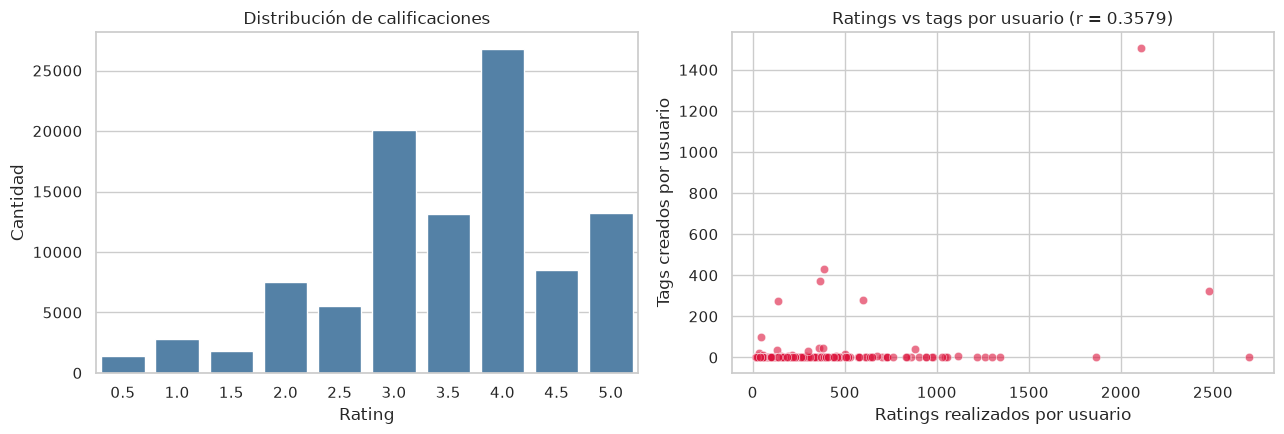

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(x=ratings["rating"], color="steelblue", ax=axes[0])
axes[0].set(title="Distribución de calificaciones", xlabel="Rating", ylabel="Cantidad")
sns.scatterplot(data=actividad, x="ratings", y="tags", alpha=0.6, color="crimson", ax=axes[1])
axes[1].set(title=f"Ratings vs tags por usuario (r = {correlacion:.4f})",
            xlabel="Ratings realizados por usuario", ylabel="Tags creados por usuario")
fig.tight_layout()
plt.show()

---
<a id="pregunta-6"></a>

## 6. ¿Cuál es la variable objetivo, qué clases tiene y qué modelo usaron?

**Respuesta:**

- **Variable objetivo:** `rating_alto` (binaria).
- **Clases:** 0 = rating bajo (< 4): 52.256 casos (51,8%). 1 = rating alto (≥ 4): 48.580 casos (48,2%). Están casi balanceadas.
- **Modelo:** árbol de decisión (`DecisionTreeClassifier`), visto en clase. Como referencia se compara con una regresión logística ([sección 9.1](#seccion-9-1)).
- **Por qué un árbol:** sus reglas se pueden leer, capta relaciones no lineales, no necesita normalizar las variables y muestra la importancia de cada una.
- **Configuración:** `max_depth=6` y `min_samples_leaf=50` para evitar el sobreajuste, `class_weight="balanced"` y `random_state=42`.

<a id="seccion-6-1"></a>

### 6.1 Clases y configuración del modelo

Se cuentan los casos de cada clase y se define el árbol con su configuración.

In [16]:
clases = y.value_counts().sort_index().to_frame("cantidad")
clases.index = ["0 = Rating bajo (< 4)", "1 = Rating alto (>= 4)"]
clases["%"] = clases["cantidad"] / clases["cantidad"].sum() * 100
display(clases)

arbol = DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, class_weight="balanced", random_state=SEED)
print(arbol)

,cantidad,%
0 = Rating bajo (< 4),52256,51.8228
1 = Rating alto (>= 4),48580,48.1772


DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=50, random_state=42)


---
<a id="pregunta-7"></a>

## 7. ¿Qué proporción usaron para entrenamiento/prueba y cómo separaron?

**Respuesta:** 80% para entrenamiento y 20% para prueba en los dos modelos.

- **Árbol de decisión:** `train_test_split(test_size=0.20, random_state=42, stratify=y)`. Quedan 80.668 casos para entrenar y 20.168 para probar, ambos con 48,18% de ratings altos.
- **Recomendador:** permutación aleatoria con semilla 42. Quedan 800.167 para entrenar y 200.042 para probar, sin filas compartidas.
- El conjunto de prueba no se usa para entrenar, y las métricas se calculan solo sobre él.

**Fuga de información detectada:**

- **Árbol:** las estadísticas del usuario se calcularon antes de dividir. Recalculándolas solo con entrenamiento, el ROC-AUC baja de 0,7264 a 0,7231 y el recall de 0,6986 a 0,6516; el accuracy queda igual (0,658). La fuga infla sobre todo el recall ([sección 7.3](#seccion-7-3)).
- **Recomendador:** la parada temprana de [`03b_mf_numpy.py`](WRANGLER/04_modelado/scripts/03b_mf_numpy.py) elige la mejor época mirando el RMSE de prueba. Lo correcto sería elegirla con una partición de validación aparte.

<a id="seccion-7-1"></a>

### 7.1 División y entrenamiento del árbol

Se separa el 20% para prueba conservando la proporción de clases, y el árbol se entrena solo con el 80% restante.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)
print(f"Entrenamiento: {len(X_train):,} ({len(X_train) / len(X):.0%}) | Prueba: {len(X_test):,} ({len(X_test) / len(X):.0%})")
print(f"% rating alto -> entrenamiento: {y_train.mean():.2%} | prueba: {y_test.mean():.2%}")
arbol.fit(X_train, y_train)

Entrenamiento: 80,668 (80%) | Prueba: 20,168 (20%)
% rating alto -> entrenamiento: 48.18% | prueba: 48.18%


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_fea

<a id="seccion-7-2"></a>

### 7.2 División del recomendador

Se comprueba que la división de la [sección 2.1](#seccion-2-1) no comparte ninguna calificación entre entrenamiento y prueba.

In [18]:
print(f"Entrenamiento: {len(tr_idx):,} | Prueba: {len(te_idx):,}")
print(f"Calificaciones compartidas: {len(np.intersect1d(tr_idx, te_idx))}")

Entrenamiento: 800,167 | Prueba: 200,042


Calificaciones compartidas: 0


<a id="seccion-7-3"></a>

### 7.3 Efecto de la fuga de información

Se entrena el mismo árbol, pero con la media y el conteo de cada usuario calculados solo con los datos de entrenamiento, y se comparan las métricas.

In [19]:
def metricas_clasificacion(modelo, X_eval, y_eval):
    pred = modelo.predict(X_eval)
    prob = modelo.predict_proba(X_eval)[:, 1]
    return {"accuracy": accuracy_score(y_eval, pred),
            "balanced_accuracy": balanced_accuracy_score(y_eval, pred),
            "precision": precision_score(y_eval, pred, zero_division=0),
            "recall": recall_score(y_eval, pred, zero_division=0),
            "f1": f1_score(y_eval, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_eval, prob),
            "average_precision": average_precision_score(y_eval, prob)}


df_train, df_test = df.loc[X_train.index], df.loc[X_test.index]
stats_train = df_train.groupby("userId")["rating"].agg(user_mean_rating="mean", user_rating_count="count")


def features_sin_fuga(parte):
    f = parte[["userId", "genre_count", "year"]].join(stats_train, on="userId")
    f["user_mean_rating"] = f["user_mean_rating"].fillna(df_train["rating"].mean())
    f["user_rating_count"] = f["user_rating_count"].fillna(0)
    return f[FEATURES]


arbol_sin_fuga = DecisionTreeClassifier(**arbol.get_params()).fit(features_sin_fuga(df_train), y_train)
fuga = pd.DataFrame({
    "con fuga": metricas_clasificacion(arbol, X_test, y_test),
    "sin fuga": metricas_clasificacion(arbol_sin_fuga, features_sin_fuga(df_test), y_test),
}).loc[["accuracy", "recall", "roc_auc"]]
display(fuga)

,con fuga,sin fuga
accuracy,0.6581,0.6584
recall,0.6986,0.6516
roc_auc,0.7264,0.7231


---
<a id="pregunta-8"></a>

## 8. ¿Cuáles son las variables más importantes y cómo lo determinaron?

**Respuesta:**

- **Método:** importancia de variables (`feature_importances_`) del árbol: cuánto ayuda cada variable a separar las clases en las divisiones del árbol.
- **Resultado:** user_mean_rating 0,9413; year 0,0413; user_rating_count 0,0140; genre_count 0,0034.
- **Interpretación:** el árbol decide casi solo por la nota media del usuario (94% de la importancia). Los usuarios que suelen poner notas altas tienden a dar ratings altos. La cantidad de géneros de una película casi no ayuda.
- **Cuidado:** la importancia muestra qué usa el modelo para decidir, no qué causa un rating alto. Además, parte del peso de user_mean_rating viene de la fuga de información ([sección 7.3](#seccion-7-3)).

<a id="seccion-8-1"></a>

### 8.1 Importancia de variables

Se ordena la importancia que el árbol entrenado asigna a cada variable.

,variable,importancia
0,user_mean_rating,0.9413
1,year,0.0413
2,user_rating_count,0.0140
3,genre_count,0.0034


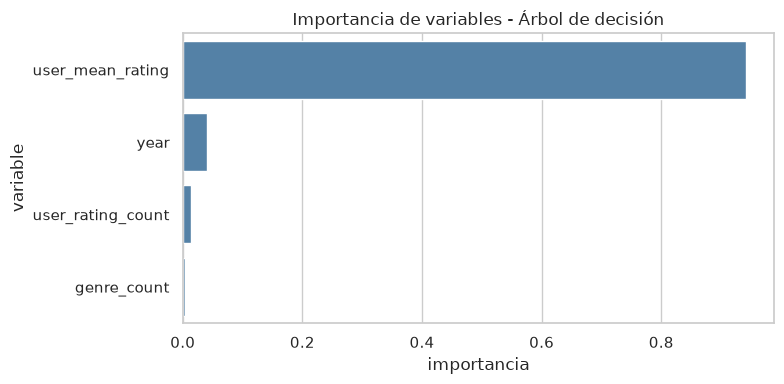

In [20]:
importancia = (pd.DataFrame({"variable": FEATURES, "importancia": arbol.feature_importances_})
               .sort_values("importancia", ascending=False).reset_index(drop=True))
display(importancia)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=importancia, x="importancia", y="variable", color="steelblue", ax=ax)
ax.set_title("Importancia de variables - Árbol de decisión")
fig.tight_layout()
plt.show()

---
<a id="pregunta-9"></a>

## 9. ¿Qué desempeño obtuvo el modelo y qué error reducir?

**Respuesta (árbol de decisión, 20.168 casos de prueba):**

| Métrica | Árbol de decisión | Línea base (clase mayoritaria) | Regresión logística |
|---|---:|---:|---:|
| Accuracy | 0,6581 | 0,5182 | 0,6563 |
| Balanced accuracy | 0,6595 | 0,5000 | 0,6572 |
| Precision | 0,6311 | 0,0000 | 0,6332 |
| Recall | 0,6986 | 0,0000 | 0,6814 |
| F1 | 0,6631 | 0,0000 | 0,6564 |
| ROC-AUC | 0,7264 | 0,5000 | 0,7220 |

- **Matriz de confusión:** 6.484 verdaderos negativos, 3.968 falsos positivos, 2.928 falsos negativos y 6.788 verdaderos positivos.
- **Error más importante a reducir:** los **falsos negativos (2.928)**, es decir, predecir que un rating será bajo cuando en realidad es alto. En un recomendador, dejar de recomendar una buena película cuesta más que recomendar una mediocre. Los **falsos positivos (3.968)** también importan, porque recomendar algo que el usuario no quiere empeora su experiencia.
- **Comparación:** el árbol supera a la línea base por 14 puntos de accuracy y en ROC-AUC (0,73 frente a 0,50). Con la regresión logística queda prácticamente empatado, lo que indica que el límite está en las variables, no en el algoritmo.

**Respuesta (recomendador, MovieLens 1M):** RMSE 0,851 y MAE 0,669 en prueba ([sección 2.3](#seccion-2-3)).

- **CN-1** (MAE < 0,70): **cumple**, 0,669.
- **CN-2** (mejora ≥ 10% frente a popularidad): **cumple**, 12,9%.
- **CN-3** (Top-10 cubre > 31,9% del catálogo): **no cumple**, 21,2% (787 de 3.706 películas). Queda como trabajo pendiente.
- **CN-4** (recomendaciones para los 6.040 usuarios): **cumple**.
- **Precision@10:** de cada 10 películas recomendadas, el 80,4% tenía 4 estrellas o más, frente al 77,2% con popularidad (4.368 usuarios).

<a id="seccion-9-1"></a>

### 9.1 Métricas del árbol frente a otros modelos

Se compara el árbol con una línea base que siempre predice la clase más frecuente y con una regresión logística entrenada con las mismas variables y la misma división.

In [21]:
linea_base = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
reg_logistica = make_pipeline(StandardScaler(),
                              LogisticRegression(class_weight="balanced", max_iter=1000)).fit(X_train, y_train)
comparacion = pd.DataFrame({
    "Árbol de decisión": metricas_clasificacion(arbol, X_test, y_test),
    "Línea base": metricas_clasificacion(linea_base, X_test, y_test),
    "Regresión logística": metricas_clasificacion(reg_logistica, X_test, y_test),
})
display(comparacion)

,Árbol de decisión,Línea base,Regresión logística
accuracy,0.6581,0.5182,0.6563
balanced_accuracy,0.6595,0.5000,0.6572
precision,0.6311,0.0000,0.6332
recall,0.6986,0.0000,0.6814
f1,0.6631,0.0000,0.6564
roc_auc,0.7264,0.5000,0.7220
average_precision,0.6954,0.4818,0.7003


<a id="seccion-9-2"></a>

### 9.2 Matriz de confusión

Muestra los aciertos y errores del árbol en el conjunto de prueba.

VN = 6,484 | FP = 3,968 | FN = 2,928 | VP = 6,788


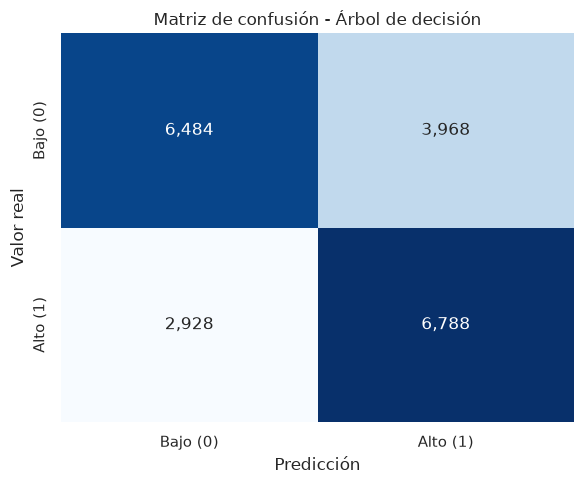

In [22]:
cm = confusion_matrix(y_test, arbol.predict(X_test))
(vn, fp), (fn, vp) = cm
print(f"VN = {vn:,} | FP = {fp:,} | FN = {fn:,} | VP = {vp:,}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Bajo (0)", "Alto (1)"], yticklabels=["Bajo (0)", "Alto (1)"], ax=ax)
ax.set(xlabel="Predicción", ylabel="Valor real", title="Matriz de confusión - Árbol de decisión")
fig.tight_layout()
plt.show()

<a id="seccion-9-3"></a>

### 9.3 Criterios de negocio del recomendador

Con el modelo de la [sección 2.2](#seccion-2-2) se arma el Top-10 de cada usuario, con películas que no vio, y se revisa cada criterio de la pregunta 1.

In [23]:
puntajes = mu_mf + bu[:, None] + bi[None, :] + P @ Q.T
puntajes[U_tr, I_tr] = -np.inf
top10 = np.argpartition(-puntajes, 10, axis=1)[:, :10]
cobertura = len(np.unique(top10)) / n_i
usuarios_con_top10 = int(np.isfinite(np.take_along_axis(puntajes, top10, axis=1)).all(axis=1).sum())
mejora_pop = (rmse_pop - rmse_mf) / rmse_pop

criterios = pd.DataFrame([
    ("CN-1", "MAE < 0.70", f"{mae_mf:.4f}", mae_mf < 0.70),
    ("CN-2", "mejora RMSE >= 10% vs popularidad", f"{mejora_pop:.1%}", mejora_pop >= 0.10),
    ("CN-3", "Top-10 cubre > 31.9% del catálogo", f"{cobertura:.1%} ({len(np.unique(top10)):,} de {n_i:,})", cobertura > 0.319),
    ("CN-4", "Top-10 para los 6,040 usuarios", f"{usuarios_con_top10:,} de {n_u:,}", usuarios_con_top10 == n_u),
], columns=["criterio", "meta", "resultado", "cumple"])
display(criterios)

,criterio,meta,resultado,cumple
0,CN-1,MAE < 0.70,0.6686,True
1,CN-2,mejora RMSE >= 10% vs popularidad,12.9%,True
2,CN-3,Top-10 cubre > 31.9% del catálogo,"21.2% (787 de 3,706)",False
3,CN-4,"Top-10 para los 6,040 usuarios","6,040 de 6,040",True


<a id="seccion-9-4"></a>

### 9.4 Precision@10 frente a popularidad

Para cada usuario con al menos 10 calificaciones de prueba se toman las 10 que el modelo puntúa más alto y se mide cuántas tenían 4 estrellas o más. Lo mismo con el ranking por popularidad. Código de [`03c_antes_despues.py`](WRANGLER/04_modelado/scripts/03c_antes_despues.py).

In [24]:
usuarios_mf = cod_u.cat.categories
peliculas_mf = cod_i.cat.categories
votos_train = train.groupby("movieId").size()
popularidad = media_pelicula.where(votos_train >= 50)
n_prueba = test.groupby("userId").size()

precision_10 = []
for usuario, grupo in test[test["userId"].isin(n_prueba[n_prueba >= 10].index)].groupby("userId"):
    u_cod = usuarios_mf.get_loc(usuario)
    i_cod = peliculas_mf.get_indexer(grupo["movieId"])
    pred_modelo = np.clip(mu_mf + bu[u_cod] + bi[i_cod] + Q[i_cod] @ P[u_cod], 1, 5)
    pred_popular = np.nan_to_num(grupo["movieId"].map(popularidad).to_numpy(float))
    reales = grupo["rating"].to_numpy()
    precision_10.append(((reales[np.argsort(-pred_modelo)[:10]] >= 4).mean(),
                         (reales[np.argsort(-pred_popular)[:10]] >= 4).mean()))
precision_10 = np.array(precision_10)
print(f"Usuarios evaluados: {len(precision_10):,}")
print(f"Precision@10 -> modelo: {precision_10[:, 0].mean():.1%} | popularidad: {precision_10[:, 1].mean():.1%}")

Usuarios evaluados: 4,368
Precision@10 -> modelo: 80.4% | popularidad: 77.2%


---
<a id="pregunta-10"></a>

## 10. ¿Qué visualización permite entender cómo toma decisiones el modelo?

**Respuesta:** El gráfico del árbol ([sección 10.1](#seccion-10-1)) y la tabla de sus ramas ([sección 10.2](#seccion-10-2)). Leídos juntos muestran cómo decide:

- La primera pregunta del árbol es: ¿la nota media del usuario es 3,50 o menos? En entrenamiento, el 48,2% de los ratings son altos.
- **Si es mayor a 3,50:** el 63,7% de los ratings son altos. Si además supera 3,81 sube al 74,7%, y por encima de 4,07 llega al 82,9%. El árbol predice "Alto".
- **Si es 3,50 o menos:** el 31,5% son altos. Por debajo de 3,25 baja al 22,7%. El árbol predice "Bajo".
- **Entre 3,25 y 3,50** el árbol mira el año: 46,1% de ratings altos si la calificación es de 2002 o antes, y 38,1% si es posterior.
- Casi todas las divisiones usan user_mean_rating, lo que coincide con su importancia de 0,94 (pregunta 8).

**Aporte:** permite explicar a personas no técnicas por qué se predice un rating alto o bajo, y comprobar que el modelo usa variables razonables y no ruido.

<a id="seccion-10-1"></a>

### 10.1 Gráfico del árbol (primeros tres niveles)

Se muestran los primeros niveles para que el gráfico sea legible. Los valores del gráfico están ponderados por `class_weight="balanced"`; por eso la [sección 10.2](#seccion-10-2) calcula el porcentaje real de ratings altos en cada rama.

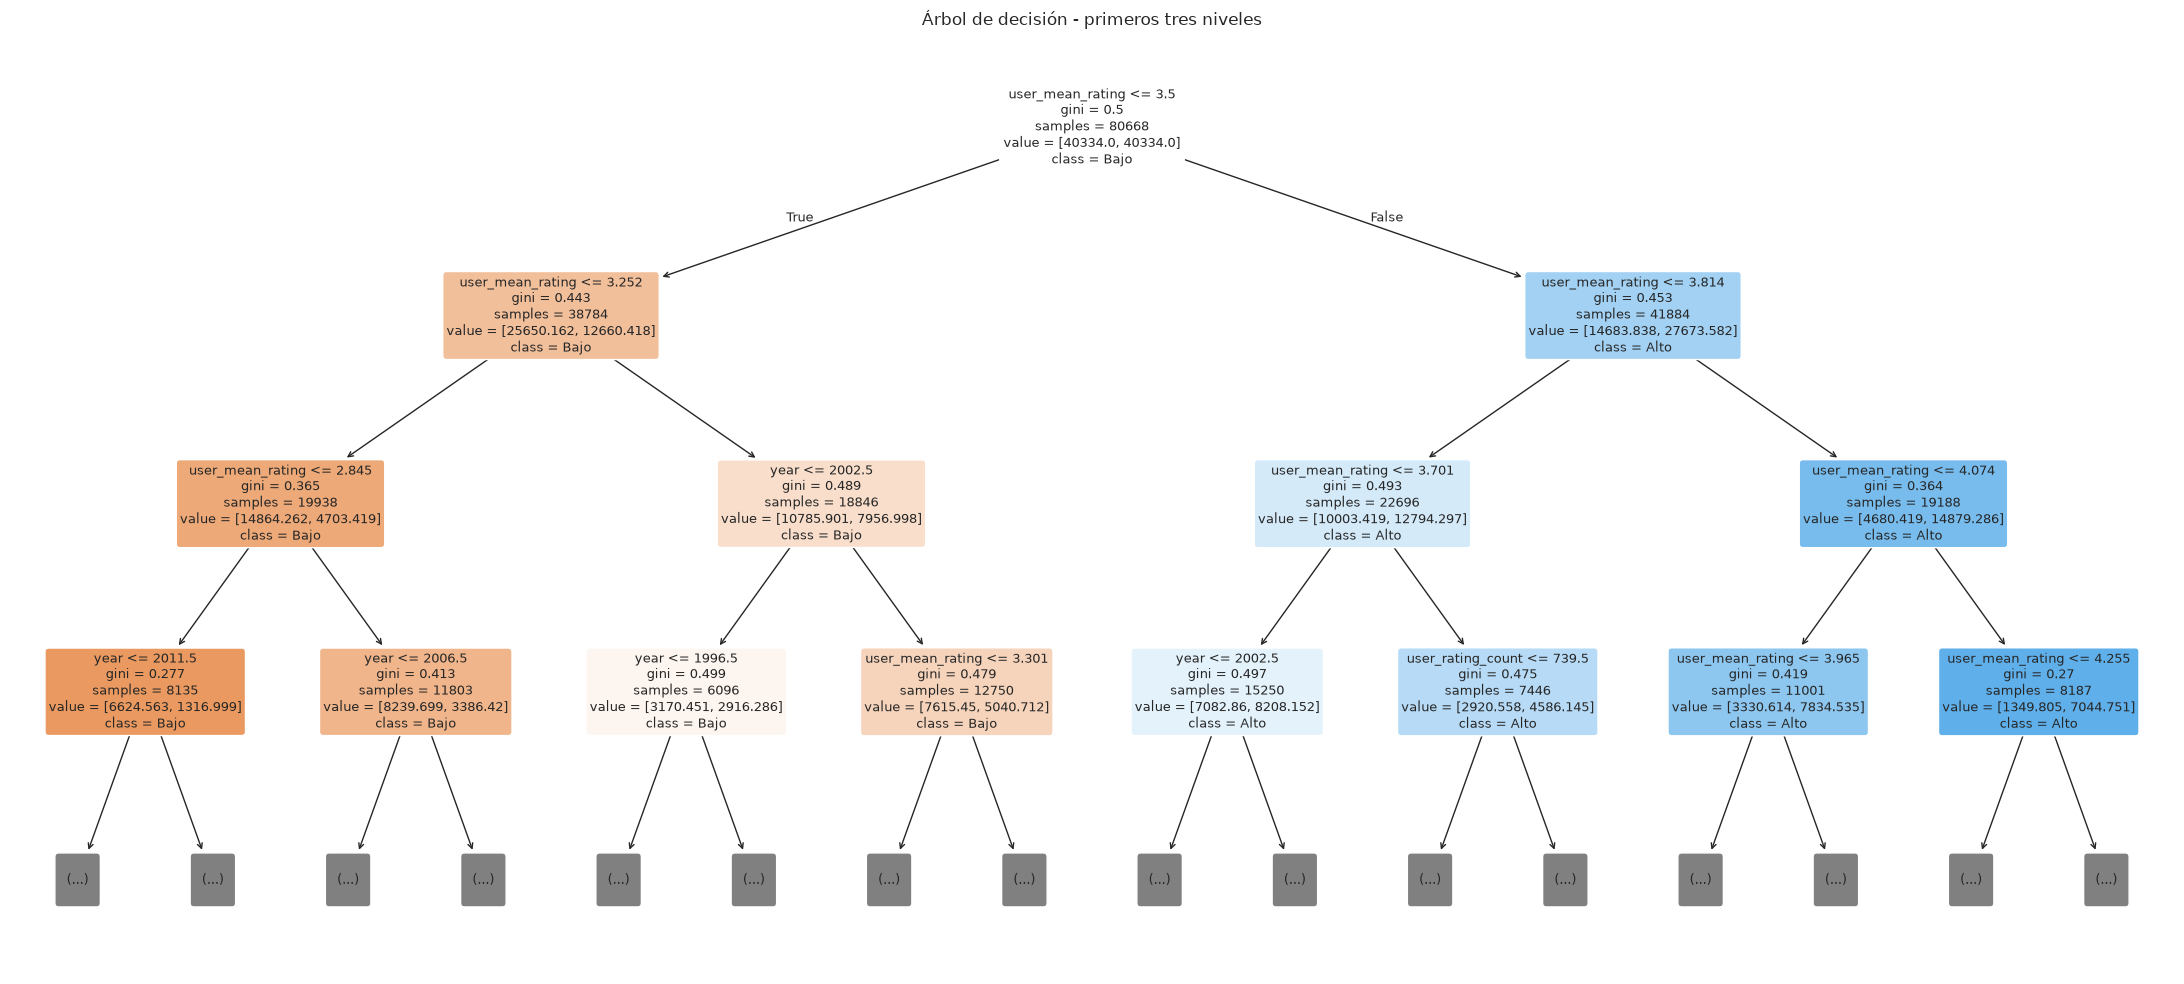

In [25]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(arbol, feature_names=FEATURES, class_names=["Bajo", "Alto"], filled=True,
          rounded=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title("Árbol de decisión - primeros tres niveles")
fig.tight_layout()
plt.show()

<a id="seccion-10-2"></a>

### 10.2 Reglas y porcentaje real de ratings altos por rama

Las reglas en texto muestran las condiciones del árbol; la tabla indica cuántos casos de entrenamiento llegan a cada rama y qué porcentaje de ellos es rating alto.

In [26]:
print(export_text(arbol, feature_names=FEATURES, max_depth=2))

nodos = arbol.decision_path(X_train)
t = arbol.tree_
izq, der = t.children_left, t.children_right
ramas = {
    "raíz": 0,
    "user_mean_rating <= 3.50": izq[0],
    "user_mean_rating > 3.50": der[0],
    "user_mean_rating <= 3.25": izq[izq[0]],
    "3.25 < user_mean_rating <= 3.50": der[izq[0]],
    "   y year <= 2002": izq[der[izq[0]]],
    "   y year > 2002": der[der[izq[0]]],
    "3.50 < user_mean_rating <= 3.81": izq[der[0]],
    "user_mean_rating > 3.81": der[der[0]],
    "user_mean_rating > 4.07": der[der[der[0]]],
}
filas = []
for nombre, nodo in ramas.items():
    llega = nodos[:, nodo].toarray().ravel().astype(bool)
    filas.append((nombre, int(llega.sum()), y_train[llega].mean() * 100))
display(pd.DataFrame(filas, columns=["rama", "casos de entrenamiento", "% rating alto"]))

|--- user_mean_rating <= 3.50
|   |--- user_mean_rating <= 3.25
|   |   |--- user_mean_rating <= 2.84
|   |   |   |--- truncated branch of depth 4
|   |   |--- user_mean_rating >  2.84
|   |   |   |--- truncated branch of depth 4
|   |--- user_mean_rating >  3.25
|   |   |--- year <= 2002.50
|   |   |   |--- truncated branch of depth 4
|   |   |--- year >  2002.50
|   |   |   |--- truncated branch of depth 4
|--- user_mean_rating >  3.50
|   |--- user_mean_rating <= 3.81
|   |   |--- user_mean_rating <= 3.70
|   |   |   |--- truncated branch of depth 4
|   |   |--- user_mean_rating >  3.70
|   |   |   |--- truncated branch of depth 4
|   |--- user_mean_rating >  3.81
|   |   |--- user_mean_rating <= 4.07
|   |   |   |--- truncated branch of depth 4
|   |   |--- user_mean_rating >  4.07
|   |   |   |--- truncated branch of depth 4



,rama,casos de entrenamiento,% rating alto
0,raíz,80668,48.1777
1,user_mean_rating <= 3.50,38784,31.4537
2,user_mean_rating > 3.50,41884,63.6639
3,user_mean_rating <= 3.25,19938,22.7305
4,3.25 < user_mean_rating <= 3.50,18846,40.6824
5,y year <= 2002,6096,46.0958
6,y year > 2002,12750,38.0941
7,3.50 < user_mean_rating <= 3.81,22696,54.3179
8,user_mean_rating > 3.81,19188,74.7186
9,user_mean_rating > 4.07,8187,82.9119


---
## Resumen: dónde está el código de cada respuesta

| Pregunta | Código en este cuaderno | Origen |
|---|---|---|
| [1. Problema y criterios de éxito](#pregunta-1) | [1.1](#seccion-1-1) | [`3_1_objetivo_del_negocio.txt`](WRANGLER/01_comprension_negocio/3_1_objetivo_del_negocio.txt) |
| [2. Métrica principal (RMSE)](#pregunta-2) | [2.1](#seccion-2-1), [2.2](#seccion-2-2), [2.3](#seccion-2-3) | [`03a_baselines.py`](WRANGLER/04_modelado/scripts/03a_baselines.py), [`03b_mf_numpy.py`](WRANGLER/04_modelado/scripts/03b_mf_numpy.py) |
| [3. Unidad de análisis y dimensiones](#pregunta-3) | [3.1](#seccion-3-1) | [`datos_limpios.parquet`](WRANGLER/03_preparacion_datos/datos/datos_limpios.parquet), [`ml-latest-small`](ml-latest-small/README.txt) |
| [4. Calidad y preparación](#pregunta-4) | [4.1](#seccion-4-1), [4.2](#seccion-4-2), [4.3](#seccion-4-3) | [`script.py`](script.py), [`arbol_decision_movielens.ipynb`](arbol_decision_movielens.ipynb) |
| [5. Hallazgo de la exploración](#pregunta-5) | [5.1](#seccion-5-1), [5.2](#seccion-5-2) | [`script.py`](script.py) |
| [6. Variable objetivo y modelo](#pregunta-6) | [6.1](#seccion-6-1) | [`arbol_decision_movielens.ipynb`](arbol_decision_movielens.ipynb) |
| [7. División y fuga de información](#pregunta-7) | [7.1](#seccion-7-1), [7.2](#seccion-7-2), [7.3](#seccion-7-3) | [`arbol_decision_movielens.ipynb`](arbol_decision_movielens.ipynb), [`03a_baselines.py`](WRANGLER/04_modelado/scripts/03a_baselines.py) |
| [8. Importancia de variables](#pregunta-8) | [8.1](#seccion-8-1) | [`arbol_decision_movielens.ipynb`](arbol_decision_movielens.ipynb) |
| [9. Desempeño y error a reducir](#pregunta-9) | [9.1](#seccion-9-1), [9.2](#seccion-9-2), [9.3](#seccion-9-3), [9.4](#seccion-9-4) | [`arbol_decision_movielens.ipynb`](arbol_decision_movielens.ipynb), [`03c_antes_despues.py`](WRANGLER/04_modelado/scripts/03c_antes_despues.py) |
| [10. Visualización de decisiones](#pregunta-10) | [10.1](#seccion-10-1), [10.2](#seccion-10-2) | [`arbol_decision_movielens.ipynb`](arbol_decision_movielens.ipynb) |

**Notas:**

- El WRANGLER describe MovieLens 1M, pero el árbol de decisión usa ml-latest-small. Unificar ambos datasets queda pendiente.
- El RMSE 0,873 de SVD citado en [`3_1_objetivo_del_negocio.txt`](WRANGLER/01_comprension_negocio/3_1_objetivo_del_negocio.txt) se midió con la librería scikit-surprise, que no está instalada. Por eso aquí se usa la factorización matricial de [`03b_mf_numpy.py`](WRANGLER/04_modelado/scripts/03b_mf_numpy.py), que se reentrena en el cuaderno y da 0,851.
- El baseline "media + sesgos" da 0,905 con [`03a_baselines.py`](WRANGLER/04_modelado/scripts/03a_baselines.py). El 0,930 que aparece en los documentos de negocio es de una medición anterior.